Age
35    0.053061
34    0.052381
36    0.046939
31    0.046939
29    0.046259
32    0.041497
30    0.040816
33    0.039456
38    0.039456
40    0.038776
37    0.034014
27    0.032653
28    0.032653
42    0.031293
39    0.028571
45    0.027891
41    0.027211
26    0.026531
44    0.022449
46    0.022449
43    0.021769
50    0.020408
24    0.017687
25    0.017687
49    0.016327
47    0.016327
55    0.014966
53    0.012925
48    0.012925
51    0.012925
54    0.012245
52    0.012245
22    0.010884
56    0.009524
23    0.009524
58    0.009524
21    0.008844
20    0.007483
59    0.006803
19    0.006122
18    0.005442
60    0.003401
57    0.002721
Name: proportion, dtype: float64

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

DailyRate
691.0     0.004082
408.0     0.003401
1082.0    0.003401
530.0     0.003401
1329.0    0.003401
            ...   
1378.0    0.000680
468.0     0.000680
613.0     0.000680
1023.0    0.000680
628.0     0.000680
Name: proportion, Leng

C:\Users\AdedayoAdenrele\AppData\Local\Temp\ipykernel_2284\3320047066.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


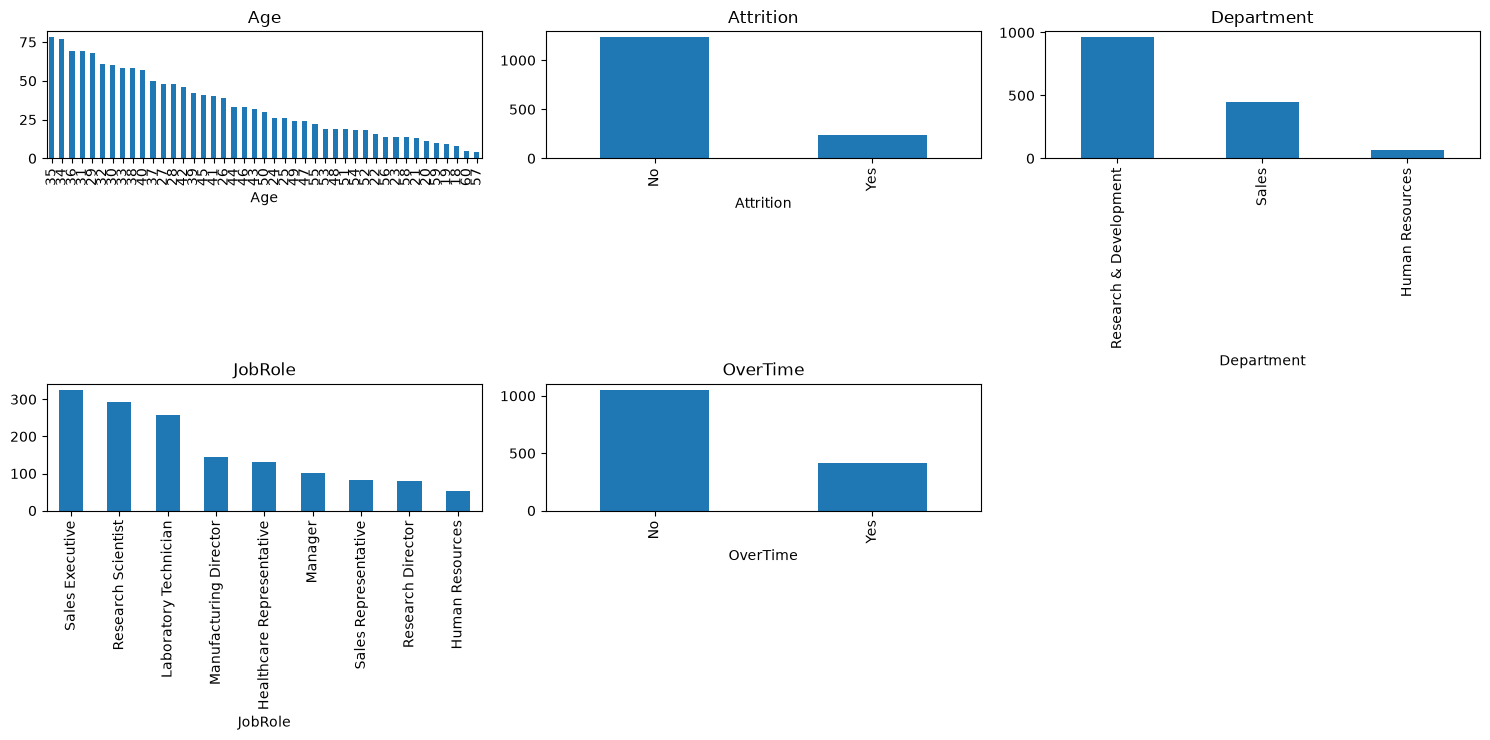

In [3]:
%run data_preprocessing.ipynb

In [8]:
data=pd.read_csv('../data/Employee_Attrition_cleaned.csv')
data.head()

,Age,Attrition,DailyRate,Department,DistanceFromHome,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobRole,...,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,TotalWorkingYears,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion
0,41,Yes,1102.0,Sales,1.0,2.0,94.0,3.0,2.0,Sales Executive,...,8.0,Yes,11.0,3.0,1.0,8.0,1.0,6.0,4.0,0.0
1,49,No,279.0,Research & Development,8.0,3.0,61.0,2.0,2.0,Research Scientist,...,1.0,No,23.0,4.0,4.0,10.0,3.0,10.0,7.0,1.0
2,37,Yes,1373.0,Research & Development,2.0,4.0,92.0,2.0,1.0,Laboratory Technician,...,6.0,Yes,15.0,3.0,2.0,7.0,3.0,0.0,0.0,0.0
3,33,No,1392.0,Research & Development,3.0,4.0,56.0,3.0,1.0,Research Scientist,...,1.0,Yes,11.0,3.0,3.0,8.0,3.0,8.0,7.0,3.0
4,27,No,591.0,Research & Development,2.0,1.0,40.0,3.0,1.0,Laboratory Technician,...,9.0,No,12.0,3.0,4.0,6.0,3.0,2.0,2.0,2.0


In [15]:
from sklearn.preprocessing import LabelEncoder

data_encoded = data.copy()
for col in data_encoded.select_dtypes(include='object').columns:
    data_encoded[col] = LabelEncoder().fit_transform(data_encoded[col])

X = data_encoded.drop('Attrition', axis=1)
y = data_encoded['Attrition']

C:\Users\AdedayoAdenrele\AppData\Local\Temp\ipykernel_2284\2908552224.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data_encoded.select_dtypes(include='object').columns:


**Splitting my data- train/test split**

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**SMOTE**

In [22]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(y_train_resampled.value_counts())

Attrition
0    986
1    986
Name: count, dtype: int64


**Training my model**

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_resampled, y_train_resampled)

y_pred = model.predict(X_test)

c:\Users\AdedayoAdenrele\Downloads\Employee_Attrition\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
y_pred

array([1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0])

In [26]:
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})
print(comparison)

   Actual  Predicted
0       0          1
1       0          0
2       0          1
3       0          0
4       1          1
5       0          1
6       0          0
7       0          0
8       0          0
9       0          1
